# S5 Contrastive SSL Colab

This notebook builds a Colab-friendly S5 self-supervised learning baseline on Utah-array cache shards stored in Google Drive.

It supports two contrastive objectives behind one switch:

- `future_infonce`: CPC-style future-state InfoNCE over S5 hidden states.
- `augment_infonce`: same-window augmentation contrastive learning over pooled segment embeddings.

The notebook keeps the existing `s5_future_prediction.ipynb` data-loading pattern:

- mount Google Drive
- clone the public repo
- copy cache data to `/content`
- train from local disk
- save logs, checkpoints, and plots back to Drive


In [1]:
# Mount Drive and resolve cache / output roots.
from google.colab import drive
from pathlib import Path


drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive")
cache_candidates = [
    DRIVE_ROOT / "utah_ssl" / "data" / "cache_v1",
    DRIVE_ROOT / "utah_ssl" / "data" / "cache_v1_fused",
    DRIVE_ROOT / "utah_ssl" / "data" / "v1_cache",
    DRIVE_ROOT / "utah_ssl" / "data" / "v1_cache_fused",
    DRIVE_ROOT / "cache_v1",
    DRIVE_ROOT / "cache_v1_fused",
    DRIVE_ROOT / "v1_cache",
    DRIVE_ROOT / "v1_cache_fused",
]
CACHE_ROOT = next((p for p in cache_candidates if p.exists()), cache_candidates[0])
OUTPUT_ROOT = DRIVE_ROOT / "utah_ssl" / "outputs" / "ssl_experiments" / "contrastive"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("DRIVE_ROOT :", DRIVE_ROOT)
print("CACHE_ROOT :", CACHE_ROOT, "| exists:", CACHE_ROOT.exists())
print("OUTPUT_ROOT:", OUTPUT_ROOT, "| exists:", OUTPUT_ROOT.exists())

if CACHE_ROOT.exists():
    datasets = sorted(p.name for p in CACHE_ROOT.iterdir() if p.is_dir())
    print("datasets:", datasets)
else:
    print("cache candidates checked:")
    for path in cache_candidates:
        print(" -", path)


Mounted at /content/drive
DRIVE_ROOT : /content/drive/MyDrive
CACHE_ROOT : /content/drive/MyDrive/utah_ssl/data/cache_v1 | exists: True
OUTPUT_ROOT: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive | exists: True
datasets: ['000950', 'brain2text24', 'brain2text25', 'motor_data', 'plug_n_play', 'unsupervised_cursor_recalibration_offline', 'unsupervised_cursor_recalibration_online', 'willett_handwriting']


In [3]:
# Clone the public repo and import the reusable contrastive SSL helpers.
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/ethan-read/utah-ssl.git"
REPO_DIR = Path("/content/utah-ssl")
EXPERIMENTS_DIR = REPO_DIR / "analysis" / "active" / "ssl_experiments"
CONTRASTIVE_SSL_DIR = EXPERIMENTS_DIR / "contrastive_ssl"
SSL_DIR = REPO_DIR / "analysis" / "active" / "transfer_benchmark" / "ssl_autoresearch"

os.chdir("/content")

if REPO_DIR.exists():
    print("Using existing repo:", REPO_DIR)
else:
    subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)

os.chdir(REPO_DIR)

for candidate in (REPO_DIR, EXPERIMENTS_DIR, SSL_DIR):
    candidate_str = str(candidate)
    if candidate_str not in sys.path:
        sys.path.insert(0, candidate_str)

os.environ["SSL_AUTORESEARCH_CACHE_ROOT"] = str(CACHE_ROOT)
os.environ["SSL_AUTORESEARCH_OUTPUT_ROOT"] = str(OUTPUT_ROOT)

if not CONTRASTIVE_SSL_DIR.exists():
    raise FileNotFoundError(
        "The cloned repo does not contain analysis/active/ssl_experiments/contrastive_ssl. "
        "If you are running this notebook from Colab, make sure REPO_DIR points at a repo checkout that includes the refactor."
    )

from contrastive_ssl import (
    CacheAccessConfig,
    DownstreamProbeConfig,
    SSLTrainingConfig,
    build_random_init_probe_state,
    build_segment_sampler,
    plot_ssl_training_history,
    prepare_cache_context,
    recover_downstream_probe_state,
    run_downstream_probe,
    run_probe_head_sweep,
    run_ssl_training,
)

try:
    from contrastive_ssl import list_ssl_checkpoints
except ImportError:
    from contrastive_ssl.training import list_ssl_checkpoints

print("cwd:", Path.cwd())
print("repo dir exists:", REPO_DIR.exists(), REPO_DIR)
print("experiments dir exists:", EXPERIMENTS_DIR.exists(), EXPERIMENTS_DIR)
print("contrastive_ssl dir exists:", CONTRASTIVE_SSL_DIR.exists(), CONTRASTIVE_SSL_DIR)
print("ssl dir exists:", SSL_DIR.exists(), SSL_DIR)
print("SSL_AUTORESEARCH_CACHE_ROOT:", os.environ["SSL_AUTORESEARCH_CACHE_ROOT"])
print("SSL_AUTORESEARCH_OUTPUT_ROOT:", os.environ["SSL_AUTORESEARCH_OUTPUT_ROOT"])


Using existing repo: /content/utah-ssl


ImportError: cannot import name 'list_ssl_checkpoints' from 'contrastive_ssl' (/content/utah-ssl/analysis/active/ssl_experiments/contrastive_ssl/__init__.py)

In [ ]:
# Experiment config.
SEED = 7
OBJECTIVE_MODE = "future_infonce"
SEGMENT_BINS = 64
# With patch_size=5 and stride=1, horizon=5 makes the target patch start strictly after the current patch.
FUTURE_HORIZONS = (6,)
PATCH_SIZE = 4
PATCH_STRIDE = 2
HIDDEN_SIZE = 256
S5_STATE_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.1
BATCH_SIZE = 32
NUM_STEPS = 2000
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-2
TEMPERATURE = 0.1
VAL_EVERY = 50
VAL_BATCHES = 10
CHECKPOINT_EVERY_STEPS = 100
DATASET_WEIGHT_ALPHA = 0.25
EXAMPLES_PER_SHARD = 8
POST_PROJ_NORM = "rms"
CACHE_ACCESS_MODE = "copy_to_local"
# CACHE_ACCESS_MODE = "drive_direct"

LOCAL_CACHE_BASE = "/content/utah_ssl_cache"
FORCE_RECOPY_LOCAL_CACHE = False
EXCLUDED_DATASETS = {"brain2text25"}
LOG_EVERY = 10
# SSL pretraining now uses session-level featurewise z-scoring by default.
NORMALIZE_IMPL_VERSION = "session_featurewise_v1"
NORMALIZE_CONTEXT_BINS = min(16, SEGMENT_BINS)  # Used only by the segment_prefix_v1 fallback.

AUGMENT_CFG = {
    "noise_std": 0.01,
    "scale_jitter": 0.05,
    "offset_jitter": 0.05,
    "time_mask_frac": 0.10,
    "channel_dropout_prob": 0.05,
    "clip_value": 20.0,
}

CACHE_ACCESS_CONFIG = CacheAccessConfig(
    mode=CACHE_ACCESS_MODE,
    local_cache_base=LOCAL_CACHE_BASE,
    force_recopy_local_cache=FORCE_RECOPY_LOCAL_CACHE,
    excluded_datasets=tuple(sorted(EXCLUDED_DATASETS)),
    seed=SEED,
    segment_bins=SEGMENT_BINS,
    normalize_context_bins=NORMALIZE_CONTEXT_BINS,
    normalize_impl_version=NORMALIZE_IMPL_VERSION,
    examples_per_shard=EXAMPLES_PER_SHARD,
)
SSL_TRAINING_CONFIG = SSLTrainingConfig(
    seed=SEED,
    objective_mode=OBJECTIVE_MODE,
    segment_bins=SEGMENT_BINS,
    future_horizons=FUTURE_HORIZONS,
    patch_size=PATCH_SIZE,
    patch_stride=PATCH_STRIDE,
    hidden_size=HIDDEN_SIZE,
    s5_state_size=S5_STATE_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    batch_size=BATCH_SIZE,
    num_steps=NUM_STEPS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    temperature=TEMPERATURE,
    val_every=VAL_EVERY,
    val_batches=VAL_BATCHES,
    checkpoint_every_steps=CHECKPOINT_EVERY_STEPS,
    dataset_weight_alpha=DATASET_WEIGHT_ALPHA,
    examples_per_shard=EXAMPLES_PER_SHARD,
    log_every=LOG_EVERY,
    post_proj_norm=POST_PROJ_NORM,
    augment_cfg=dict(AUGMENT_CFG),
)

print("SSL patch config:", {
    "patch_size": PATCH_SIZE,
    "patch_stride": PATCH_STRIDE,
    "future_horizons": FUTURE_HORIZONS,
})
print("SSL checkpoint cadence:", CHECKPOINT_EVERY_STEPS)
print("SSL normalization config:", {
    "normalize_impl_version": NORMALIZE_IMPL_VERSION,
    "normalize_context_bins_fallback": NORMALIZE_CONTEXT_BINS,
})
print("CACHE_ACCESS_CONFIG:", CACHE_ACCESS_CONFIG)
print("SSL_TRAINING_CONFIG:", SSL_TRAINING_CONFIG)


CACHE_ACCESS_CONFIG: CacheAccessConfig(mode='copy_to_local', local_cache_base='/content/utah_ssl_cache', force_recopy_local_cache=False, excluded_datasets=('brain2text25',), seed=7, segment_bins=64, normalize_context_bins=16, normalize_impl_version='segment_prefix_v1', examples_per_shard=8, tx_dim=256, sbp_dim=256, shard_cache_ram_gb=None)
SSL_TRAINING_CONFIG: SSLTrainingConfig(seed=7, objective_mode='future_infonce', segment_bins=64, future_horizons=(1, 3), patch_size=3, patch_stride=1, hidden_size=256, s5_state_size=128, num_layers=2, dropout=0.1, batch_size=32, num_steps=2000, learning_rate=0.0003, weight_decay=0.01, temperature=0.1, val_every=50, val_batches=10, dataset_weight_alpha=0.25, examples_per_shard=8, log_every=10, post_proj_norm='rms', augment_cfg={'noise_std': 0.01, 'scale_jitter': 0.05, 'offset_jitter': 0.05, 'time_mask_frac': 0.1, 'channel_dropout_prob': 0.05, 'clip_value': 20.0})


In [ ]:
# Resolve cache access mode, summarize datasets, and build the reusable cache context.
import os

CACHE_CONTEXT = prepare_cache_context(
    cache_candidates=cache_candidates,
    config=CACHE_ACCESS_CONFIG,
)

DRIVE_CACHE_ROOT = CACHE_CONTEXT.drive_cache_root
CACHE_ROOT = CACHE_CONTEXT.cache_root
ACTIVE_CACHE_ROOT = CACHE_CONTEXT.cache_root
CACHE_COPY_USED = CACHE_CONTEXT.cache_copy_used
SOURCE_CACHE_SIGNATURE = CACHE_CONTEXT.source_cache_signature
available_datasets = CACHE_CONTEXT.available_datasets
pretrain_datasets = CACHE_CONTEXT.pretrain_datasets
session_split_summary = CACHE_CONTEXT.session_split_summary
SHARD_STORE = CACHE_CONTEXT.shard_store
SHARD_CACHE_RAM_GB = SHARD_STORE.summary()["budget_gb"]
HAS_VAL_DATASETS = CACHE_CONTEXT.has_val_datasets
TX_DIM = CACHE_CONTEXT.tx_dim
SBP_DIM = CACHE_CONTEXT.sbp_dim
FULL_DIM = CACHE_CONTEXT.full_dim
NORMALIZE_IMPL_VERSION = CACHE_CONTEXT.normalize_impl_version
NORMALIZE_CONTEXT_BINS = CACHE_CONTEXT.normalize_context_bins
SSL_SESSION_STATS_COUNT = len(CACHE_CONTEXT.session_feature_stats)

os.environ["SSL_AUTORESEARCH_CACHE_ROOT"] = str(CACHE_ROOT)

print("CACHE_ACCESS_MODE:", CACHE_ACCESS_CONFIG.mode)
print("CACHE_COPY_USED:", CACHE_COPY_USED)
print("ACTIVE_CACHE_ROOT:", CACHE_ROOT)
print("NORMALIZE_IMPL_VERSION:", NORMALIZE_IMPL_VERSION)
print("NORMALIZE_CONTEXT_BINS (fallback only):", NORMALIZE_CONTEXT_BINS)
print("SSL_SESSION_STATS_COUNT:", SSL_SESSION_STATS_COUNT)
print("SHARD_CACHE_RAM_GB:", SHARD_CACHE_RAM_GB)
print("available datasets:")
for name in available_datasets:
    tag = "excluded" if name in EXCLUDED_DATASETS else "included"
    print(f" - {name} [{tag}]")
print("session split summary:")
for dataset in pretrain_datasets:
    summary = session_split_summary[dataset]
    print(
        f" - {dataset}: sessions={summary['total_sessions']} train_sessions={summary['train_sessions']} "
        f"val_sessions={summary['val_sessions']} train_examples={summary['train_examples']} "
        f"val_examples={summary['val_examples']} val_eligible={summary['val_eligible']}"
    )
print("shard cache:", SHARD_STORE.summary())


copying cache to local disk...
source: /content/drive/MyDrive/utah_ssl/data/cache_v1
source signature: 875d5322885b
dest  : /content/utah_ssl_cache/cache_v1
copy plan: 9 top-level entries, 608 files, 30.3 GB total
starting 1/9 000950
progress [1/9 000950]: files=8/608 bytes=266.3 MB/30.3 GB rate=16.3 MB/s elapsed=16.3s
progress [1/9 000950]: files=14/608 bytes=286.0 MB/30.3 GB rate=12.4 MB/s elapsed=23.1s
starting 2/9 brain2text24
progress [2/9 brain2text24]: files=17/608 bytes=475.7 MB/30.3 GB rate=12.0 MB/s elapsed=39.5s
progress [2/9 brain2text24]: files=20/608 bytes=705.4 MB/30.3 GB rate=11.5 MB/s elapsed=61.1s
progress [2/9 brain2text24]: files=23/608 bytes=920.4 MB/30.3 GB rate=11.0 MB/s elapsed=83.5s
progress [2/9 brain2text24]: files=29/608 bytes=1.2 GB/30.3 GB rate=11.8 MB/s elapsed=104.8s
progress [2/9 brain2text24]: files=32/608 bytes=1.4 GB/30.3 GB rate=11.6 MB/s elapsed=122.8s
progress [2/9 brain2text24]: files=35/608 bytes=1.6 GB/30.3 GB rate=11.4 MB/s elapsed=141.8s
prog

In [ ]:
# Sampler smoke test.
from collections import Counter

INSPECT_BATCH_SIZE = 8
inspect_train_sampler = build_segment_sampler(
    CACHE_CONTEXT,
    "train",
    batch_size=INSPECT_BATCH_SIZE,
    seed=SEED,
    segment_bins=SEGMENT_BINS,
    dataset_weight_alpha=DATASET_WEIGHT_ALPHA,
    examples_per_shard=EXAMPLES_PER_SHARD,
)
inspect_batch = inspect_train_sampler.sample_batch()

print("train batch shapes:")
print(" - x           :", tuple(inspect_batch["x"].shape))
print(" - feature_mask:", tuple(inspect_batch["feature_mask"].shape))
print(" - lengths     :", tuple(inspect_batch["lengths"].shape))
print(" - dataset mix :", Counter(inspect_batch["datasets"]))
print(" - session keys:", inspect_batch["session_keys"][:3])

if HAS_VAL_DATASETS:
    inspect_val_sampler = build_segment_sampler(
        CACHE_CONTEXT,
        "val",
        batch_size=min(INSPECT_BATCH_SIZE, 4),
        seed=SEED + 1,
        segment_bins=SEGMENT_BINS,
        dataset_weight_alpha=DATASET_WEIGHT_ALPHA,
        examples_per_shard=EXAMPLES_PER_SHARD,
    )
    inspect_val_batch = inspect_val_sampler.sample_batch()
    print("\nval batch shapes:")
    print(" - x           :", tuple(inspect_val_batch["x"].shape))
    print(" - feature_mask:", tuple(inspect_val_batch["feature_mask"].shape))
    print(" - lengths     :", tuple(inspect_val_batch["lengths"].shape))
    print(" - dataset mix :", Counter(inspect_val_batch["datasets"]))
else:
    print("\nNo validation sampler was built because all datasets are single-session.")


train batch shapes:
 - x           : (8, 64, 512)
 - feature_mask: (8, 512)
 - lengths     : (8,)
 - dataset mix : Counter({'willett_handwriting': 2, 'unsupervised_cursor_recalibration_online': 2, '000950': 1, 'unsupervised_cursor_recalibration_offline': 1, 'motor_data': 1, 'brain2text24': 1})
 - session keys: ['000950:sub-T5-held-in-calib_ses-20220525', 'unsupervised_cursor_recalibration_offline:t5.2019.04.01', 'willett_handwriting:t5.2019.05.08']

val batch shapes:
 - x           : (4, 64, 512)
 - feature_mask: (4, 512)
 - lengths     : (4,)
 - dataset mix : Counter({'motor_data': 2, 'willett_handwriting': 1, 'unsupervised_cursor_recalibration_online': 1})


In [ ]:
# Runtime summary.
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
print("FULL_DIM:", FULL_DIM)
print("pretrain_datasets:", pretrain_datasets)
print("HAS_VAL_DATASETS:", HAS_VAL_DATASETS)


DEVICE: cuda
FULL_DIM: 512
pretrain_datasets: ['000950', 'brain2text24', 'motor_data', 'plug_n_play', 'unsupervised_cursor_recalibration_offline', 'unsupervised_cursor_recalibration_online', 'willett_handwriting']
HAS_VAL_DATASETS: True


In [ ]:
# Run the selected contrastive SSL objective.
SSL_RUN_STATE = run_ssl_training(
    cache_context=CACHE_CONTEXT,
    config=SSL_TRAINING_CONFIG,
    output_root=OUTPUT_ROOT,
    device=DEVICE,
)

# Backward-compatible globals for downstream cells.
model = SSL_RUN_STATE["model"]
optimizer = SSL_RUN_STATE["optimizer"]
TRAIN_SAMPLER = SSL_RUN_STATE["train_sampler"]
VAL_SAMPLER = SSL_RUN_STATE["val_sampler"]
run_name = SSL_RUN_STATE["run_name"]
run_dir = SSL_RUN_STATE["run_dir"]
progress_path = SSL_RUN_STATE["progress_path"]
checkpoint_path = SSL_RUN_STATE["checkpoint_path"]
checkpoints_dir = SSL_RUN_STATE["checkpoints_dir"]
plot_loss_path = SSL_RUN_STATE["plot_loss_path"]
plot_top1_path = SSL_RUN_STATE["plot_top1_path"]
config = SSL_RUN_STATE["config"]
best_score = SSL_RUN_STATE["best_score"]
best_step = SSL_RUN_STATE["best_step"]
train_history = SSL_RUN_STATE["train_history"]
val_history = SSL_RUN_STATE["val_history"]

print("SSL_RUN_STATE ready:", run_dir)
print("SSL final checkpoint:", checkpoint_path)
print("SSL step checkpoints dir:", checkpoints_dir)
print("SSL best step:", best_step)


In [ ]:
# Plot training curves for the latest SSL run.
if "SSL_RUN_STATE" not in globals():
    raise RuntimeError("Run the SSL training cell first so SSL_RUN_STATE is defined.")

SSL_PLOT_STATE = plot_ssl_training_history(SSL_RUN_STATE)


## Downstream Probe Workflow

This section is split into five groups:
1. configure and preview the held-out Brain2Text25 probe split
2. recover the default encoder state and optionally inspect saved SSL checkpoints
3. run frozen-encoder comparisons with shared frozen-probe settings
4. run full fine-tuning comparisons with shared notebook `B2` settings
5. inspect saved summaries, diagnostics, and train curves

Only change the shared override dictionaries in the helper cell below when you want to alter probe budgets.
That keeps the SSL vs random-init comparisons aligned.


In [ ]:
# Benchmark-lite downstream phoneme probe config.
DOWNSTREAM_PROBE_EXPLICIT_CHECKPOINT_PATH = None
# Example: DOWNSTREAM_PROBE_EXPLICIT_CHECKPOINT_PATH = str((Path(run_dir) / "checkpoints" / "step_000500.pt"))

PROBE_HEAD_LEARNING_RATE = 1e-3
ENCODER_LEARNING_RATE = 1e-4
PROBE_WEIGHT_DECAY = 1e-2

DOWNSTREAM_PROBE_CONFIG = DownstreamProbeConfig(
    enabled=True,
    seed=SEED,
    comparison_mode="ssl_only",
    session_limit=8,
    target_session_count=4,
    adaptation_regime="A",
    probe_batch_size=8,
    probe_budget_seconds=240,
    max_probe_steps=400,
    progress_every_steps=25,
    progress_every_seconds=15.0,
    probe_head_learning_rate=PROBE_HEAD_LEARNING_RATE,
    encoder_learning_rate=ENCODER_LEARNING_RATE,
    weight_decay=PROBE_WEIGHT_DECAY,
    probe_head_type="linear",
    probe_lstm_hidden_size=64,
    probe_conv_hidden_size=128,
    probe_conv_kernel_size=3,
    checkpoint_source="most_recent_valid_then_in_memory",
    explicit_checkpoint_path=DOWNSTREAM_PROBE_EXPLICIT_CHECKPOINT_PATH,
)
DOWNSTREAM_PROBE_SUMMARY_BASENAME = DOWNSTREAM_PROBE_CONFIG.summary_basename

print("DOWNSTREAM_PROBE_CONFIG:", DOWNSTREAM_PROBE_CONFIG)
print(
    "Downstream optimizer config:",
    {
        "probe_head_learning_rate": PROBE_HEAD_LEARNING_RATE,
        "encoder_learning_rate": ENCODER_LEARNING_RATE,
        "weight_decay": PROBE_WEIGHT_DECAY,
    },
)


DOWNSTREAM_PROBE_CONFIG: DownstreamProbeConfig(enabled=True, seed=7, comparison_mode='ssl_only', session_limit=8, target_session_count=4, adaptation_regime='A', probe_batch_size=8, probe_budget_seconds=240, max_probe_steps=400, progress_every_steps=25, progress_every_seconds=15.0, probe_head_type='linear', probe_lstm_hidden_size=64, probe_conv_hidden_size=128, probe_conv_kernel_size=3, checkpoint_source='most_recent_valid_then_in_memory', summary_basename='downstream_probe_summary.json')


In [ ]:
# Import and validate benchmark-lite downstream probe helpers from the current repo checkout.
from pathlib import Path

from contrastive_ssl.probe import build_downstream_probe_problem

CANONICAL_B2T25_ROOT = Path(CACHE_ROOT) / "brain2text25"
CANONICAL_B2T25_MANIFEST_PATH = CANONICAL_B2T25_ROOT / "manifest.jsonl"
CANONICAL_B2T25_METADATA_PATH = CANONICAL_B2T25_ROOT / "metadata.json"

if not CANONICAL_B2T25_MANIFEST_PATH.exists() or not CANONICAL_B2T25_METADATA_PATH.exists():
    raise FileNotFoundError(
        "Canonical Brain2Text25 cache manifest / metadata is missing from the mounted cache. "
        f"Expected {CANONICAL_B2T25_MANIFEST_PATH} and {CANONICAL_B2T25_METADATA_PATH}."
    )

downstream_probe_problem_preview = build_downstream_probe_problem(
    cache_root=Path(CACHE_ROOT),
    probe_config=DOWNSTREAM_PROBE_CONFIG,
)
downstream_probe_metadata_preview = downstream_probe_problem_preview["metadata"]

if "phoneme_vocabulary" not in downstream_probe_metadata_preview:
    raise KeyError("Canonical Brain2Text25 metadata is missing 'phoneme_vocabulary'.")

downstream_probe_eligible_entries = downstream_probe_problem_preview["eligible_entries"]
downstream_probe_split_preview = downstream_probe_problem_preview["split"]

print("BENCHMARK_HELPER_SOURCE:", "contrastive_ssl_package")
print("Canonical Brain2Text25 probe assets:")
print(" - root:", CANONICAL_B2T25_ROOT)
print(" - manifest:", CANONICAL_B2T25_MANIFEST_PATH)
print(" - metadata:", CANONICAL_B2T25_METADATA_PATH)
print(" - eligible_sessions:", len(downstream_probe_eligible_entries))
print(" - preview_source_sessions:", [entry.session_base for entry in downstream_probe_split_preview.train])
print(" - preview_target_sessions:", [entry.session_base for entry in downstream_probe_split_preview.val])


BENCHMARK_HELPER_SOURCE: contrastive_ssl_package
Canonical Brain2Text25 probe assets:
 - root: /content/utah_ssl_cache/cache_v1/brain2text25
 - manifest: /content/utah_ssl_cache/cache_v1/brain2text25/manifest.jsonl
 - metadata: /content/utah_ssl_cache/cache_v1/brain2text25/metadata.json
 - eligible_sessions: 45
 - preview_source_sessions: ['t15.2024.07.21', 't15.2024.07.28', 't15.2025.01.10', 't15.2025.01.12']
 - preview_target_sessions: ['t15.2025.03.14', 't15.2025.03.16', 't15.2025.03.30', 't15.2025.04.13']


In [ ]:
# Recover the default SSL encoder and prepare reusable downstream probe state.
DOWNSTREAM_PROBE_DEFAULT_STATE = recover_downstream_probe_state(
    probe_config=DOWNSTREAM_PROBE_CONFIG,
    output_root=OUTPUT_ROOT,
    input_dim=FULL_DIM,
    default_checkpoint_config=SSL_TRAINING_CONFIG.checkpoint_config(),
    in_memory_model=SSL_RUN_STATE["model"] if "SSL_RUN_STATE" in globals() else None,
    current_checkpoint_path=Path(checkpoint_path) if "checkpoint_path" in globals() else None,
    current_run_dir=Path(run_dir) if "run_dir" in globals() else None,
)
DOWNSTREAM_PROBE_BASE_RUN_DIR = Path(DOWNSTREAM_PROBE_DEFAULT_STATE["base_run_dir"])
DOWNSTREAM_PROBE_RUN_DIR = DOWNSTREAM_PROBE_BASE_RUN_DIR
DOWNSTREAM_PROBE_CHECKPOINT_PATH = DOWNSTREAM_PROBE_DEFAULT_STATE["checkpoint_path"]
DOWNSTREAM_PROBE_CHECKPOINT_CONFIG = dict(DOWNSTREAM_PROBE_DEFAULT_STATE["checkpoint_config"])
DOWNSTREAM_PROBE_ENCODER_SOURCE = str(DOWNSTREAM_PROBE_DEFAULT_STATE["source"])
DOWNSTREAM_PROBE_ENCODER = DOWNSTREAM_PROBE_DEFAULT_STATE["encoder"]

print("DOWNSTREAM_PROBE_EXPLICIT_CHECKPOINT_PATH:", DOWNSTREAM_PROBE_EXPLICIT_CHECKPOINT_PATH)
print("DOWNSTREAM_PROBE_ENCODER_SOURCE:", DOWNSTREAM_PROBE_ENCODER_SOURCE)
print("DOWNSTREAM_PROBE_BASE_RUN_DIR:", DOWNSTREAM_PROBE_BASE_RUN_DIR)
print("DOWNSTREAM_PROBE_CHECKPOINT_PATH:", DOWNSTREAM_PROBE_CHECKPOINT_PATH)
print("DOWNSTREAM_PROBE_CHECKPOINT_SELECTION:", DOWNSTREAM_PROBE_CONFIG.checkpoint_source)
print("DOWNSTREAM_PROBE_ENCODER:", DOWNSTREAM_PROBE_ENCODER)


DOWNSTREAM_PROBE_ENCODER_SOURCE: checkpoint
DOWNSTREAM_PROBE_BASE_RUN_DIR: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260406T155149Z
DOWNSTREAM_PROBE_CHECKPOINT_PATH: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260406T155149Z/checkpoint_final.pt
DOWNSTREAM_PROBE_CHECKPOINT_SELECTION: most_recent_valid_then_in_memory
DOWNSTREAM_PROBE_ENCODER: NotebookProbeEncoderAdapter(
  (encoder): S5ContrastiveEncoder(
    (proj): Linear(in_features=1536, out_features=256, bias=True)
    (post_proj_norm): RMSNorm()
    (backbone): S5SequenceBackbone(
      (blocks): ModuleList(
        (0-1): 2 x S5Block(
          (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (ssm): DiagonalS5SSM(
            (D): Linear(in_features=256, out_features=256, bias=False)
          )
          (dropout1): Dropout(p=0.1, inplace=False)
          (norm2): LayerNorm((256,), eps=1e-05, e

In [ ]:
# List saved SSL checkpoints for the current run so probes can target an intermediate step.
import pandas as pd

CHECKPOINT_LIST_RUN_DIR = Path(run_dir) if "run_dir" in globals() else DOWNSTREAM_PROBE_BASE_RUN_DIR
AVAILABLE_SSL_CHECKPOINTS = list_ssl_checkpoints(CHECKPOINT_LIST_RUN_DIR)
AVAILABLE_SSL_CHECKPOINTS_DF = pd.DataFrame(AVAILABLE_SSL_CHECKPOINTS)

display(AVAILABLE_SSL_CHECKPOINTS_DF)
print("CHECKPOINT_LIST_RUN_DIR:", CHECKPOINT_LIST_RUN_DIR)
print(
    "To probe an intermediate checkpoint, set DOWNSTREAM_PROBE_EXPLICIT_CHECKPOINT_PATH to one of the paths above, "
    "then rerun the downstream probe config and recovery cells."
)


In [ ]:
# Shared downstream experiment helpers.
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

FROZEN_LINEAR_PROBE_OVERRIDES = {
    "probe_head_type": "linear",
}

QUICK_CONV1D_PROBE_OVERRIDES = {
    "probe_head_type": "conv1d",
    "probe_conv_hidden_size": DOWNSTREAM_PROBE_DEFAULT_STATE["encoder"].hidden_size,
    "probe_conv_kernel_size": 3,
    "probe_budget_seconds": 120,
    "max_probe_steps": 50,
}

B2_LINEAR_PROBE_OVERRIDES = {
    "probe_head_type": "linear",
    "probe_head_learning_rate": PROBE_HEAD_LEARNING_RATE,
    "encoder_learning_rate": ENCODER_LEARNING_RATE,
    "weight_decay": PROBE_WEIGHT_DECAY,
    "probe_budget_seconds": 600,
    "max_probe_steps": 800,
}

SUMMARY_DISPLAY_COLUMNS = [
    "model_variant",
    "train_encoder",
    "probe_head_type",
    "probe_head_num_parameters",
    "probe_head_learning_rate",
    "encoder_learning_rate",
    "target_session_ids",
    "target_train_examples",
    "target_val_examples",
    "val_ctc_bpphone",
    "val_phoneme_error_rate",
    "most_common_prediction",
    "most_common_prediction_rate",
    "most_common_false_prediction",
    "most_common_false_prediction_rate",
    "top_substitution_pair",
    "probe_steps",
    "probe_elapsed_seconds",
]

COMPARISON_DISPLAY_COLUMNS = [
    "model_variant",
    "train_encoder",
    "probe_head_type",
    "probe_head_learning_rate",
    "encoder_learning_rate",
    "val_ctc_bpphone",
    "val_phoneme_error_rate",
    "most_common_prediction",
    "most_common_prediction_rate",
    "most_common_false_prediction",
    "most_common_false_prediction_rate",
    "top_substitution_pair",
    "probe_steps",
    "probe_elapsed_seconds",
]


def build_notebook_random_probe_state(*, seed_offset: int = 0):
    return build_random_init_probe_state(
        reference_config=DOWNSTREAM_PROBE_DEFAULT_STATE["checkpoint_config"],
        input_dim=FULL_DIM,
        seed=SEED + int(seed_offset),
        base_run_dir=DOWNSTREAM_PROBE_BASE_RUN_DIR,
    )


def run_notebook_probe(
    summary_name: str,
    *,
    probe_state: dict,
    variant_prefix: str,
    artifact_prefix: str,
    train_encoder: bool,
    probe_overrides: dict | None = None,
    comparison_mode: str | None = None,
) -> dict:
    summary = run_downstream_probe(
        probe_state=probe_state,
        probe_config=DOWNSTREAM_PROBE_CONFIG,
        cache_root=CACHE_ROOT,
        device=DEVICE,
        variant_prefix=variant_prefix,
        artifact_prefix=artifact_prefix,
        train_encoder=train_encoder,
        probe_overrides=probe_overrides,
        comparison_mode=comparison_mode,
    )
    globals()[summary_name] = summary
    display(pd.DataFrame([summary])[SUMMARY_DISPLAY_COLUMNS])
    print(f"{summary_name.lower()}_summary_path:", Path(summary["summary_path"]))
    print(f"{summary_name.lower()}_progress_path:", Path(summary["progress_log_path"]))
    if summary.get("alignment_stats_path") is not None:
        print(f"{summary_name.lower()}_alignment_stats_path:", Path(summary["alignment_stats_path"]))
    return summary


def display_probe_comparison(summary_names: list[str], *, columns: list[str] | None = None) -> pd.DataFrame:
    rows = [globals()[name] for name in summary_names if name in globals()]
    if not rows:
        raise ValueError("None of the requested summary variables are defined in the current kernel.")
    frame = pd.DataFrame(rows)
    display(frame[columns or COMPARISON_DISPLAY_COLUMNS])
    return frame


def print_top_items(items, *, max_items: int = 8) -> None:
    if not items:
        print("  <none>")
        return
    for item in items[:max_items]:
        label = item.get("symbol", item.get("id"))
        print(f"  - {label} count={item['count']} rate={item['rate']:.3f}")


def print_substitution_items(items, *, max_items: int = 8) -> None:
    if not items:
        print("  <none>")
        return
    for item in items[:max_items]:
        print(
            f"  - {item['reference_symbol']} -> {item['predicted_symbol']} "
            f"count={item['count']} rate={item['rate']:.3f}"
        )


def print_alignment_diagnostics_from_summary(summary_name: str, *, max_items: int = 8) -> dict:
    if summary_name not in globals():
        raise NameError(f"{summary_name} is not defined in the current kernel.")
    summary = globals()[summary_name]
    stats_path = Path(summary["alignment_stats_path"])
    stats = json.loads(stats_path.read_text())

    print(f"\ndiagnostics_for: {summary_name.lower()}")
    print(" alignment_stats_path:", stats_path)
    print(" total_reference_tokens:", stats["total_reference_tokens"])
    print(" total_predicted_tokens:", stats["total_predicted_tokens"])
    print(" total_edit_distance:", stats["total_edit_distance"])
    print(" total_insertions:", stats["total_insertions"])
    print(" total_deletions:", stats["total_deletions"])
    print(" total_substitutions:", stats["total_substitutions"])

    most_common_prediction = stats.get("most_common_prediction")
    if most_common_prediction is not None:
        print(
            " most_common_prediction:",
            most_common_prediction["symbol"],
            f"count={most_common_prediction['count']} rate={most_common_prediction['rate']:.3f}",
        )

    most_common_false_prediction = stats.get("most_common_false_prediction")
    if most_common_false_prediction is not None:
        print(
            " most_common_false_prediction:",
            most_common_false_prediction["symbol"],
            f"count={most_common_false_prediction['count']} rate={most_common_false_prediction['rate']:.3f}",
        )

    top_substitution_pair = stats.get("top_substitution_pair")
    if top_substitution_pair is not None:
        print(
            " top_substitution_pair:",
            f"{top_substitution_pair['reference_symbol']} -> {top_substitution_pair['predicted_symbol']}",
            f"count={top_substitution_pair['count']} rate={top_substitution_pair['rate']:.3f}",
        )

    print(" prediction_histogram_top:")
    print_top_items(stats.get("prediction_histogram_top", []), max_items=max_items)

    print(" false_prediction_histogram_top:")
    print_top_items(stats.get("false_prediction_histogram_top", []), max_items=max_items)

    print(" insertion_histogram_top:")
    print_top_items(stats.get("insertion_histogram_top", []), max_items=max_items)

    print(" deletion_histogram_top:")
    print_top_items(stats.get("deletion_histogram_top", []), max_items=max_items)

    print(" substitution_histogram_top:")
    print_substitution_items(stats.get("substitution_histogram_top", []), max_items=max_items)
    return stats


def load_probe_progress(summary_name: str) -> pd.DataFrame:
    if summary_name not in globals():
        raise NameError(f"{summary_name} is not defined in the current kernel.")
    progress_path = Path(globals()[summary_name]["progress_log_path"])
    rows = [json.loads(line) for line in progress_path.read_text().splitlines() if line.strip()]
    return pd.DataFrame(rows)


def plot_probe_train_curves(summary_names: list[str]) -> None:
    plt.figure(figsize=(7, 4))
    plotted = False
    for summary_name in summary_names:
        if summary_name not in globals():
            continue
        frame = load_probe_progress(summary_name)
        train_rows = frame[frame["event"] == "probe_train_report"].copy()
        if train_rows.empty:
            continue
        plt.plot(train_rows["step"], train_rows["train_ctc_bpphone"], label=summary_name)
        plotted = True
    if not plotted:
        raise ValueError("None of the requested summaries include probe_train_report rows.")
    plt.xlabel("Probe Step")
    plt.ylabel("Train CTC Bits / Phoneme")
    plt.title("Downstream Probe Train Curves")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


print("FROZEN_LINEAR_PROBE_OVERRIDES:", FROZEN_LINEAR_PROBE_OVERRIDES)
print("QUICK_CONV1D_PROBE_OVERRIDES:", QUICK_CONV1D_PROBE_OVERRIDES)
print("B2_LINEAR_PROBE_OVERRIDES:", B2_LINEAR_PROBE_OVERRIDES)


FROZEN_LINEAR_PROBE_OVERRIDES: {'probe_head_type': 'linear'}
QUICK_CONV1D_PROBE_OVERRIDES: {'probe_head_type': 'conv1d', 'probe_conv_hidden_size': 256, 'probe_conv_kernel_size': 3, 'probe_budget_seconds': 120, 'max_probe_steps': 50}
B2_LINEAR_PROBE_OVERRIDES: {'probe_head_type': 'linear', 'probe_budget_seconds': 600, 'max_probe_steps': 800}


### Frozen-Encoder Comparisons

These cells keep the encoder frozen.
The two linear cells below are the main apples-to-apples frozen comparison.
The conv1d cell is a quick stronger-head diagnostic with its own smaller budget.


In [ ]:
# Frozen SSL checkpoint + linear head.
SSL_PROBE_SUMMARY = run_notebook_probe(
    "SSL_PROBE_SUMMARY",
    probe_state=DOWNSTREAM_PROBE_DEFAULT_STATE,
    variant_prefix="ssl_checkpoint",
    artifact_prefix="ssl_probe_pool4",
    train_encoder=False,
    probe_overrides=FROZEN_LINEAR_PROBE_OVERRIDES,
    comparison_mode="ssl_only_pool4",
)


KeyboardInterrupt: 

In [ ]:
# Frozen random-init baseline + linear head.
RANDOM_INIT_LINEAR_PROBE_STATE = build_notebook_random_probe_state()
RANDOM_INIT_LINEAR_PROBE_SUMMARY = run_notebook_probe(
    "RANDOM_INIT_LINEAR_PROBE_SUMMARY",
    probe_state=RANDOM_INIT_LINEAR_PROBE_STATE,
    variant_prefix="random_init",
    artifact_prefix="random_init_pool4",
    train_encoder=False,
    probe_overrides=FROZEN_LINEAR_PROBE_OVERRIDES,
    comparison_mode="random_init_pool4",
)


In [ ]:
# Optional quick stronger-head diagnostic on the frozen SSL encoder.
QUICK_CONV1D_SUMMARY = run_notebook_probe(
    "QUICK_CONV1D_SUMMARY",
    probe_state=DOWNSTREAM_PROBE_DEFAULT_STATE,
    variant_prefix="ssl_checkpoint",
    artifact_prefix="ssl_probe_quick_pool4",
    train_encoder=False,
    probe_overrides=QUICK_CONV1D_PROBE_OVERRIDES,
    comparison_mode="ssl_only_conv1d_pool4_quick",
)


In [ ]:
# Compare whichever frozen-probe summaries are currently available.
display_probe_comparison([
    "SSL_PROBE_SUMMARY",
    "RANDOM_INIT_LINEAR_PROBE_SUMMARY",
    "QUICK_CONV1D_SUMMARY",
])


### Full Fine-Tuning Comparisons

These cells run the notebook's simplified `B2` path: fine-tune the encoder and linear head together.
Both cells below use the same shared `B2_LINEAR_PROBE_OVERRIDES` dictionary on purpose.


In [ ]:
# SSL-initialized notebook B2 run.
SSL_B2_SUMMARY = run_notebook_probe(
    "SSL_B2_SUMMARY",
    probe_state=DOWNSTREAM_PROBE_DEFAULT_STATE,
    variant_prefix="ssl_checkpoint_b2",
    artifact_prefix="ssl_probe_b2_pool4",
    train_encoder=True,
    probe_overrides=B2_LINEAR_PROBE_OVERRIDES,
    comparison_mode="ssl_b2_pool4",
)


In [ ]:
# Random-init notebook B2 baseline with the exact same budget as SSL_B2.
RANDOM_INIT_B2_STATE = build_notebook_random_probe_state()
RANDOM_INIT_B2_SUMMARY = run_notebook_probe(
    "RANDOM_INIT_B2_SUMMARY",
    probe_state=RANDOM_INIT_B2_STATE,
    variant_prefix="random_init_b2",
    artifact_prefix="random_init_b2_pool4",
    train_encoder=True,
    probe_overrides=B2_LINEAR_PROBE_OVERRIDES,
    comparison_mode="random_init_b2_pool4",
)


In [ ]:
# Compare whichever notebook B2 summaries are currently available.
display_probe_comparison([
    "SSL_B2_SUMMARY",
    "RANDOM_INIT_B2_SUMMARY",
])


### Diagnostics And Curves

Set the summary names in the cells below to focus on the runs you want to inspect.
The default diagnostic cell targets the notebook `B2` pair because that is the easiest comparison to misread.


In [ ]:
# Print compact alignment diagnostics for the summaries listed here.
DIAGNOSTIC_SUMMARY_NAMES = [
    "SSL_B2_SUMMARY",
    "RANDOM_INIT_B2_SUMMARY",
]

display_probe_comparison(DIAGNOSTIC_SUMMARY_NAMES)
for summary_name in DIAGNOSTIC_SUMMARY_NAMES:
    if summary_name in globals():
        print_alignment_diagnostics_from_summary(summary_name)


ValueError: None of the requested summary variables are defined in the current kernel.

In [ ]:
# Plot train curves for any summaries that have progress logs in the current kernel.
PLOT_SUMMARY_NAMES = [
    "SSL_PROBE_SUMMARY",
    "RANDOM_INIT_LINEAR_PROBE_SUMMARY",
    "QUICK_CONV1D_SUMMARY",
    "SSL_B2_SUMMARY",
    "RANDOM_INIT_B2_SUMMARY",
]

plot_probe_train_curves(PLOT_SUMMARY_NAMES)


ValueError: None of the requested summaries include probe_train_report rows.

<Figure size 700x400 with 0 Axes>

,step,elapsed_seconds,train_ctc_bpphone
31,155,460.673,4.491081
32,161,478.176,3.905964
33,166,494.021,4.229651
34,171,509.163,3.981184
35,175,521.222,3.941682
36,181,536.682,4.491632
37,187,554.350,4.453775
38,193,572.380,4.732830
39,199,589.166,4.212487
40,200,592.183,4.807109


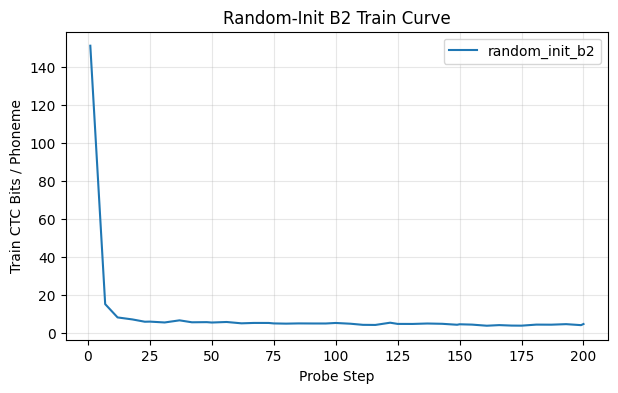

random_init_b2_final_val_ctc_bpphone: 5.451282567055353
random_init_b2_final_val_phoneme_error_rate: 0.7937562271670542


In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

random_b2_progress_path = Path(
    "/content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/"
    "colab_s5_future_infonce_seg64_20260406T155149Z/"
    "random_init_b2_pool4_linear_probe/progress.jsonl"
)

rows = [json.loads(line) for line in random_b2_progress_path.read_text().splitlines() if line.strip()]
df = pd.DataFrame(rows)

train_df = df[df["event"] == "probe_train_report"].copy()
final_df = df[df["event"] == "probe_session_complete"].copy()

display(train_df[["step", "elapsed_seconds", "train_ctc_bpphone"]].tail(10))

plt.figure(figsize=(7, 4))
plt.plot(train_df["step"], train_df["train_ctc_bpphone"], label="random_init_b2")
plt.xlabel("Probe Step")
plt.ylabel("Train CTC Bits / Phoneme")
plt.title("Random-Init B2 Train Curve")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

if not final_df.empty:
    final_row = final_df.iloc[-1]
    print("random_init_b2_final_val_ctc_bpphone:", final_row["val_ctc_bpphone"])
    print("random_init_b2_final_val_phoneme_error_rate:", final_row["val_phoneme_error_rate"])


In [ ]:
import matplotlib.pyplot as plt

def mean_cosine_vs_delta(a_source, b_source, token_lengths, max_delta=8):
    rows = []
    for delta in range(max_delta + 1):
        vals = []
        for seq_idx, length in enumerate(token_lengths.tolist()):
            length = int(length)
            usable = length - delta
            if usable <= 0:
                continue
            a = F.normalize(a_source[seq_idx, :usable], dim=-1)
            b = F.normalize(b_source[seq_idx, delta:length], dim=-1)
            vals.append((a * b).sum(dim=-1).detach().cpu())
        if vals:
            rows.append({
                "delta": delta,
                "mean_cosine": torch.cat(vals).mean().item(),
            })
    return pd.DataFrame(rows)

raw_delta_df = mean_cosine_vs_delta(tokens, tokens, token_lengths, max_delta=8)
proj_delta_df = mean_cosine_vs_delta(proj_tokens, proj_tokens, token_lengths, max_delta=8)
ssl_delta_df = mean_cosine_vs_delta(anchor_z, future_z, token_lengths, max_delta=8)

plt.figure(figsize=(7, 4))
plt.plot(raw_delta_df["delta"], raw_delta_df["mean_cosine"], marker="o", label="raw patches")
plt.plot(proj_delta_df["delta"], proj_delta_df["mean_cosine"], marker="o", label="projected patches")
plt.plot(ssl_delta_df["delta"], ssl_delta_df["mean_cosine"], marker="o", label="ssl anchor/future")
plt.xlabel("Delta (token steps)")
plt.ylabel("Mean cosine similarity")
plt.title("Similarity vs temporal offset")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


NameError: name 'tokens' is not defined